In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


### Importing libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler,StandardScaler, MaxAbsScaler
from sklearn.compose import ColumnTransformer

# !pip -q install lightgbm

import re
import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, classification_report

from lightgbm import LGBMClassifier


In [3]:
data=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
data.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
data.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [5]:
test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
test.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [6]:
sample=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
sample.head()

,ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## Apendix Milestones

In [7]:
mile_train=data.copy()
mile_test=test.copy()

##### Milestone 1

In [8]:
# Q1 What is the shape of the training dataset?
print(mile_train.shape)
# Q2 How many columns are present in the test dataset?
print(len(mile_test.columns))
# Q3 How many columns in the training dataset have object data type?
print()
print(*mile_train.select_dtypes('O').columns.to_list(), sep='\n')
print()
# Q4 How many numerical columns are present in the training dataset?
print(*mile_train.select_dtypes('number').columns.to_list(), sep='\n')
print()
# Q5 Which of the following columns is of boolean type?
print(list(mile_train.select_dtypes(['bool']).columns))
print()
# Q6 Which of the following columns have missing values?
print(mile_train.columns[mile_train.isna().any()].tolist())
print()
# Q7 How many distinct target classes are present in the dataset?
# Q8  What percentage of the dataset approximately belongs to label 0?
print(mile_train["label"].value_counts(normalize=True))
print()
# Q9  What is the median number of upvotes per comment?
print(mile_train["upvote"].median())
print()
# Q10  Which numerical feature shows the largest maximum value? upvote downvote if_1 if_2
# Q11 What is the minimum value of if_2?
print(mile_train[["upvote", "downvote", "if_1", "if_2"]].max())
print()
# Q11 What is the minimum value of if_2?
print(mile_train['if_2'].min())

(198000, 15)
14

created_date
race
religion
gender
comment

post_id
emoticon_1
emoticon_2
emoticon_3
upvote
downvote
if_1
if_2
label

['disability']

['race', 'religion', 'gender', 'comment']

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

1.0

upvote       201
downvote     107
if_1        1860
if_2        1833
dtype: int64

3


#### milestone 2

In [9]:
#Q2 Convert the created_date column into datetime objects. Identify the month that occurs the most nu
# mber of times in the dataset and enter the answer as a lowercase string

mile_train["created_date"]=pd.to_datetime(mile_train["created_date"])
mile_test["created_date"]=pd.to_datetime(mile_test["created_date"])
most_frequent_month = mile_train['created_date'].dt.month_name().value_counts().idxmax()
print(most_frequent_month.lower())
print('='*50)

# Q4 Create a new feature called total_emoticons by calculating the sum of 
# emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?

mile_train["total_emoticons"] = mile_train[["emoticon_1", "emoticon_2", "emoticon_3"]].sum(axis=1)
print(mile_train["total_emoticons"].max())
print('='*50)

""" Q4, Calculate the median character length (including spaces) of the comment column for all entries where label
is equal to 3. (Note: Treat any missing 
comments as empty strings)."""

mile_train["comment_length"] = mile_train["comment"].fillna("").str.len()
print(mile_train[mile_train["label"]==3]["comment_length"].median())
print('='*50)

""" If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], 
what would be the resulting scaled value for an
observation that originally had exactly 10 upvotes?"""

from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
mile_train["upvote_transformed"]=minmax.fit_transform(mile_train[["upvote"]])
scaled_value = mile_train[mile_train["upvote"] == 10]["upvote_transformed"].iloc[0]
print(f"The scaled value for 10 upvotes is: {scaled_value}")
print('='*50)

"""What is the average word count (number of words separated by whitespace) for comments that
are assigned a label of 1? (Round your answer to 2 decimal places)."""

mile_train["word_count"] = mile_train["comment"].fillna("").str.split().str.len()
print(mile_train[mile_train["label"] == 1]["word_count"].mean())
print('='*50)

"""How many comments in the entire dataset contain the substring "Trump"?
The search should be case-insensitive."""
print(mile_train["comment"].str.contains("Trump", case=False, na=False).sum())
print('='*50)


"""take the comment at the very first row (index 0).

- Remove all punctuation.

- Consider the following words as stop words and remove the 
same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of',
'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', '
was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', '
their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
How many words are left in the text after these two operations?"""

import string
# 1. Extract the first comment
text = str(mile_train["comment"].iloc[0])
# 2. Remove punctuation
# This creates a translation table that maps punctuation to None
text_no_punct = text.translate(str.maketrans('', '', string.punctuation))
# 3. Lowercase and split into words
words = text_no_punct.lower().split()
# 4. Define stop words
stop_words = [
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 
    'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 
    'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 
    'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 
    'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 
    'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'
]
# 5. Remove stop words
filtered_words = [w for w in words if w not in stop_words]
# 6. Result
print(len(filtered_words))
print("="*50)

"""Convert all the text in comment column to lowercase and tokenizing using whitespace.
Compute the total number of unique tokens in the dataset and enter the value"""

unique_tokens_count = (
    mile_train["comment"]
    .str.lower()
    .fillna("")
    .str.split()
    .explode()
    .nunique()
)
print(unique_tokens_count)
print('='*50)

""" Apply the TfidfVectorizer to the comment column of train.csv
with stop_words as "english", min_df as 5 and ngram_range as (1,2).
How many TF-IDF features are generated using this configuration? """
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english', 
    min_df=5, 
    ngram_range=(1, 2)
)
# 2. Fit the vectorizer to the comment column (filling NaNs with empty strings)
# fit_transform returns a sparse matrix: (n_samples, n_features)
tfidf_matrix = tfidf.fit_transform(mile_train["comment"].fillna(""))
# 3. Get the number of features
num_features = len(tfidf.get_feature_names_out())
print(f"Total TF-IDF features: {num_features}")

may
60
128.0
The scaled value for 10 upvotes is: 0.04975124378109452
57.23344641286594
24398
12
425413
Total TF-IDF features: 132974


### EDA = Exploratory Data Analysis 📊

In [10]:

train = data.copy()
my_test = test.copy()

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("\nTrain Columns:", train.columns.tolist())
print("\nTest Columns:", test.columns.tolist())


Train Shape: (198000, 15)
Test Shape: (102000, 14)

Train Columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']

Test Columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment']


In [11]:
print("=== DTYPES ===")
print(train.dtypes)

print("\n=== MISSING VALUES (Train) ===")
missing = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])

print("\n=== MISSING VALUES (Test) ===")
missing_test = pd.DataFrame({
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
})
print(missing_test[missing_test['Missing Count'] > 0])


=== DTYPES ===
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

=== MISSING VALUES (Train) ===
          Missing Count  Missing %
race             145423      73.45
religion         145423      73.45
gender           145423      73.45
comment               1       0.00

=== MISSING VALUES (Test) ===
          Missing Count  Missing %
race              75269      73.79
religion          75269      73.79
gender            75269      73.79


In [12]:
print("=== LABEL DISTRIBUTION ===")
label_counts = train['label'].value_counts().sort_index()
label_pct = (train['label'].value_counts(normalize=True).sort_index() * 100).round(2)

dist = pd.DataFrame({'Count': label_counts, 'Percentage %': label_pct})
print(dist)


=== LABEL DISTRIBUTION ===
        Count  Percentage %
label                      
0      114173         57.66
1       15918          8.04
2       62440         31.54
3        5469          2.76


In [13]:
numeric_cols = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3']

print("=== NUMERIC FEATURES SUMMARY ===")
print(train[numeric_cols].describe().T)


=== NUMERIC FEATURES SUMMARY ===
               count      mean        std  min  25%  50%   75%     max
upvote      198000.0  2.607975   5.054763  0.0  0.0  1.0   3.0   201.0
downvote    198000.0  0.666394   2.044335  0.0  0.0  0.0   1.0   107.0
if_1        198000.0  1.906152  25.635752  0.0  0.0  0.0   4.0  1860.0
if_2        198000.0  7.956212  14.839464  3.0  4.0  6.0  10.0  1833.0
emoticon_1  198000.0  0.279768   1.023234  0.0  0.0  0.0   0.0    47.0
emoticon_2  198000.0  0.048338   0.258477  0.0  0.0  0.0   0.0    11.0
emoticon_3  198000.0  0.121071   0.481013  0.0  0.0  0.0   0.0    17.0


In [14]:
numeric_cols = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3']

print("=== NUMERIC FEATURES SUMMARY ===")
print(train[numeric_cols].describe().T)


=== NUMERIC FEATURES SUMMARY ===
               count      mean        std  min  25%  50%   75%     max
upvote      198000.0  2.607975   5.054763  0.0  0.0  1.0   3.0   201.0
downvote    198000.0  0.666394   2.044335  0.0  0.0  0.0   1.0   107.0
if_1        198000.0  1.906152  25.635752  0.0  0.0  0.0   4.0  1860.0
if_2        198000.0  7.956212  14.839464  3.0  4.0  6.0  10.0  1833.0
emoticon_1  198000.0  0.279768   1.023234  0.0  0.0  0.0   0.0    47.0
emoticon_2  198000.0  0.048338   0.258477  0.0  0.0  0.0   0.0    11.0
emoticon_3  198000.0  0.121071   0.481013  0.0  0.0  0.0   0.0    17.0


In [15]:
sample_sub = sample.copy()  # or sample_submission.csv if that’s the real name
print(sample_sub.shape)
print(sample_sub.head())
print(sample_sub.tail())

print("Test rows:", len(test))
print("Sample rows:", len(sample_sub))
print("Same length?", len(test) == len(sample_sub))


(102000, 2)
   ID  label
0   1      0
1   2      0
2   3      0
3   4      0
4   5      0
            ID  label
101995  101996      0
101996  101997      0
101997  101998      0
101998  101999      0
101999  102000      0
Test rows: 102000
Sample rows: 102000
Same length? True


In [16]:
print(sample_sub['ID'].min(), sample_sub['ID'].max())
print("ID unique?", sample_sub['ID'].is_unique)

# If it's 1..102000, this will print True
print("Looks like 1..N?", (sample_sub['ID'].values == np.arange(1, len(sample_sub)+1)).all())


1 102000
ID unique? True
Looks like 1..N? True


In [17]:
print("ID in test?", 'ID' in test.columns)


ID in test? False


In [18]:
print("Null comments (train):", train['comment'].isna().sum())
print("Null comments (test):", test['comment'].isna().sum())

train_comment_empty = train['comment'].fillna('').str.strip().eq('').sum()
test_comment_empty  = test['comment'].fillna('').str.strip().eq('').sum()
print("Empty comments (train):", train_comment_empty)
print("Empty comments (test):", test_comment_empty)


Null comments (train): 1
Null comments (test): 0
Empty comments (train): 1
Empty comments (test): 0


In [19]:
tmp = train[['comment','label']].copy()
tmp['comment'] = tmp['comment'].fillna('')
tmp['char_len'] = tmp['comment'].str.len()
tmp['word_len'] = tmp['comment'].str.split().str.len()

print(tmp[['char_len','word_len']].describe(percentiles=[.5,.9,.95,.99]).T)

print("\nBy label (median/90p):")
print(tmp.groupby('label')[['char_len','word_len']].quantile([0.5,0.9]).unstack())


             count        mean         std  min    50%    90%    95%    99%  \
char_len  198000.0  302.909364  266.441749  0.0  211.0  746.0  952.0  998.0   
word_len  198000.0   52.396985   45.770221  0.0   37.0  128.0  159.0  179.0   

             max  
char_len  1892.0  
word_len   315.0  

By label (median/90p):
      char_len        word_len       
           0.5    0.9      0.5    0.9
label                                
0        199.0  749.0     35.0  129.0
1        246.0  782.0     42.0  133.0
2        232.0  749.0     40.0  129.0
3        128.0  435.0     24.0   77.0


In [20]:
tmp = train['comment'].fillna('')

flags = pd.DataFrame({
    'has_url': tmp.str.contains(r'http|www\.', regex=True).astype(int),
    'has_newline': tmp.str.contains(r'\n').astype(int),
    'has_digit': tmp.str.contains(r'\d').astype(int),
    'has_exclaim': tmp.str.contains(r'!').astype(int),
    'has_question': tmp.str.contains(r'\?').astype(int),
})

print(flags.mean().sort_values(ascending=False))
print("\nBy label:")
flags['label'] = train['label'].values
print(flags.groupby('label').mean().round(3))


has_question    0.266717
has_digit       0.222682
has_newline     0.191571
has_exclaim     0.124202
has_url         0.026106
dtype: float64

By label:
       has_url  has_newline  has_digit  has_exclaim  has_question
label                                                            
0        0.031        0.187      0.246        0.115         0.263
1        0.023        0.219      0.195        0.108         0.315
2        0.019        0.199      0.194        0.143         0.265
3        0.009        0.125      0.139        0.141         0.219


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', min_df=20, max_features=3000)
X = cv.fit_transform(train['comment'].fillna(''))

vocab = np.array(cv.get_feature_names_out())
for lab in sorted(train['label'].unique()):
    idx = (train['label'].values == lab)
    counts = np.asarray(X[idx].sum(axis=0)).ravel()
    top = counts.argsort()[-20:][::-1]
    print("\nLabel", lab, "top words:", vocab[top][:20])



Label 0 top words: ['people' 'just' 'like' 'trump' 'don' 'time' 'think' 'good' 'know' 'right'
 'years' 'did' 'make' 'government' 'way' 'state' 'need' 'does' 'money'
 'tax']

Label 1 top words: ['white' 'people' 'black' 'just' 'like' 'muslims' 'muslim' 'don' 'trump'
 'women' 'right' 'think' 'country' 'want' 'racist' 'know' 'men' 'islam'
 'gay' 'canada']

Label 2 top words: ['trump' 'people' 'like' 'just' 'don' 'right' 'think' 'time' 'know' 'good'
 'did' 'president' 'make' 'way' 'government' 'want' 'years' 'does' 'going'
 'say']

Label 3 top words: ['kill' 'people' 'just' 'like' 'don' 'trump' 'shoot' 'death' 'time'
 'killing' 'right' 'gun' 'shot' 'let' 'want' 'killed' 'good' 'think' 'die'
 'way']


In [22]:
tmp = train[['label','race','religion','gender','disability']].copy()

tmp['race_detected'] = tmp['race'].notna().astype(int)
tmp['religion_detected'] = tmp['religion'].notna().astype(int)
tmp['gender_detected'] = tmp['gender'].notna().astype(int)
tmp['disability'] = tmp['disability'].astype(int)

print(tmp.groupby('label')[['race_detected','religion_detected','gender_detected','disability']].mean().round(3))


       race_detected  religion_detected  gender_detected  disability
label                                                               
0              0.207              0.207            0.207       0.008
1              0.830              0.830            0.830       0.027
2              0.234              0.234            0.234       0.022
3              0.204              0.204            0.204       0.011


In [23]:
num_cols = ['upvote','downvote','if_1','if_2','emoticon_1','emoticon_2','emoticon_3','post_id']
g = train.groupby('label')[num_cols]

print("Means:\n", g.mean().round(3))
print("\nMedians:\n", g.median().round(3))
print("\n90th percentiles:\n", g.quantile(0.90).round(3))


Means:
        upvote  downvote   if_1    if_2  emoticon_1  emoticon_2  emoticon_3  \
label                                                                        
0       2.405     0.575  1.298   4.859       0.284       0.043       0.108   
1       2.850     0.802  8.012  11.871       0.265       0.063       0.150   
2       2.968     0.812  1.530  12.213       0.277       0.052       0.136   
3       2.036     0.514  1.129  12.621       0.277       0.071       0.134   

       post_id  
label           
0       67.765  
1       70.657  
2       69.149  
3       68.254  

Medians:
        upvote  downvote  if_1  if_2  emoticon_1  emoticon_2  emoticon_3  \
label                                                                     
0         1.0       0.0   0.0   4.0         0.0         0.0         0.0   
1         1.0       0.0   4.0  10.0         0.0         0.0         0.0   
2         1.0       0.0   0.0  10.0         0.0         0.0         0.0   
3         1.0       0.0   0.0  10.0

In [24]:
tmp = train[['label','upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']].copy()
tmp['vote_total'] = tmp['upvote'] + tmp['downvote']
tmp['vote_ratio'] = tmp['upvote'] / (tmp['vote_total'] + 1)
tmp['controversy'] = tmp['downvote'] / (tmp['upvote'] + 1)
tmp['emoticon_sum'] = tmp['emoticon_1'] + tmp['emoticon_2'] + tmp['emoticon_3']

print(tmp.groupby('label')[['vote_total','vote_ratio','controversy','emoticon_sum','if_1','if_2']].mean().round(3))


       vote_total  vote_ratio  controversy  emoticon_sum   if_1    if_2
label                                                                  
0           2.980       0.370        0.195         0.435  1.298   4.859
1           3.652       0.365        0.267         0.478  8.012  11.871
2           3.780       0.392        0.244         0.465  1.530  12.213
3           2.550       0.333        0.191         0.482  1.129  12.621


In [25]:
tmp = train[['comment','label']].copy()
tmp['comment'] = tmp['comment'].fillna('').str.strip()

dup_mask = tmp.duplicated('comment', keep=False)
dups = tmp[dup_mask].copy()

print("Duplicate comment rows:", len(dups))
print("Unique duplicated comments:", dups['comment'].nunique())

conflicts = dups.groupby('comment')['label'].nunique()
print("Conflicting-label duplicate comments:", (conflicts > 1).sum())


Duplicate comment rows: 263
Unique duplicated comments: 103
Conflicting-label duplicate comments: 5


In [26]:
num_cols = ['upvote','downvote','if_1','if_2','emoticon_1','emoticon_2','emoticon_3','post_id']
q = [0.0, 0.5, 0.9, 0.99, 1.0]

train_q = train[num_cols].quantile(q).T
test_q  = test[num_cols].quantile(q).T
train_q.columns = [f"train_q{int(p*100)}" for p in q]
test_q.columns  = [f"test_q{int(p*100)}" for p in q]

shift = pd.concat([train_q, test_q], axis=1)
print(shift)


            train_q0  train_q50  train_q90  train_q99  train_q100  test_q0  \
upvote           0.0        1.0        7.0       22.0       201.0      0.0   
downvote         0.0        0.0        2.0        9.0       107.0      0.0   
if_1             0.0        0.0        5.0       10.0      1860.0      0.0   
if_2             3.0        6.0       10.0       66.0      1833.0      4.0   
emoticon_1       0.0        0.0        1.0        4.0        47.0      0.0   
emoticon_2       0.0        0.0        0.0        1.0        11.0      0.0   
emoticon_3       0.0        0.0        0.0        2.0        17.0      0.0   
post_id         20.0       72.0      120.0      123.0       129.0     24.0   

            test_q50  test_q90  test_q99  test_q100  
upvote           1.0       7.0      23.0      189.0  
downvote         0.0       2.0       9.0       95.0  
if_1             0.0       5.0      10.0     1866.0  
if_2             6.0      10.0      66.0     1798.0  
emoticon_1       0.0       

In [27]:
post_counts = train['post_id'].value_counts()
print(post_counts.describe())

print("\nTop 10 busiest post_id:")
print(post_counts.head(10))

print("\nLabel distribution for busiest post_id:")
top_post = post_counts.index[0]
print(train.loc[train['post_id']==top_post, 'label'].value_counts(normalize=True).round(3))


count       52.000000
mean      3807.692308
std      11799.842188
min          1.000000
25%         10.000000
50%         27.500000
75%        243.750000
max      69529.000000
Name: count, dtype: float64

Top 10 busiest post_id:
post_id
72     69529
39     40946
120    24324
31     17023
73     14882
71     13308
40      5488
123     4809
118     2692
61      1149
Name: count, dtype: int64

Label distribution for busiest post_id:
label
0    0.577
2    0.311
1    0.092
3    0.020
Name: proportion, dtype: float64


In [28]:
for col in ['race','religion','gender']:
    s = train[col]
    print("\n", col)
    print("NaN %:", (s.isna().mean()*100).round(2))
    print(s.fillna('<<MISSING>>').value_counts().head(15))



 race
NaN %: 73.45
race
<<MISSING>>    145423
none            39682
white            5486
black            3869
other            1654
asian            1263
latino            623
Name: count, dtype: int64

 religion
NaN %: 73.45
religion
<<MISSING>>    145423
none            38249
christian        7191
muslim           4930
jewish           1244
other             547
atheist           219
buddhist          100
hindu              97
Name: count, dtype: int64

 gender
NaN %: 73.45
gender
<<MISSING>>    145423
none            36161
female           8037
male             7549
transgender       622
other             208
Name: count, dtype: int64


In [29]:
print("Unique post_id train:", train['post_id'].nunique())
print("Unique post_id test :", test['post_id'].nunique())

train_posts = set(train['post_id'].unique())
test_posts  = set(test['post_id'].unique())

print("Posts overlap:", len(train_posts & test_posts))
print("Posts only in train:", len(train_posts - test_posts))
print("Posts only in test :", len(test_posts - train_posts))


Unique post_id train: 52
Unique post_id test : 45
Posts overlap: 45
Posts only in train: 7
Posts only in test : 0


In [30]:
post_label = (
    train.groupby(['post_id','label'])
         .size()
         .unstack(fill_value=0)
)

post_label_pct = post_label.div(post_label.sum(axis=1), axis=0)

print("Most label-3-heavy posts:")
print(post_label_pct.sort_values(3, ascending=False).head(10))

print("\nMost label-1-heavy posts:")
print(post_label_pct.sort_values(1, ascending=False).head(10))


Most label-3-heavy posts:
label           0         1         2         3
post_id                                        
66       0.833333  0.000000  0.000000  0.166667
87       0.818182  0.000000  0.090909  0.090909
102      0.537190  0.115702  0.289256  0.057851
85       0.644231  0.028846  0.278846  0.048077
64       0.617021  0.056738  0.283688  0.042553
73       0.564507  0.060005  0.333423  0.042064
61       0.611836  0.030461  0.315927  0.041775
75       0.800000  0.000000  0.160000  0.040000
39       0.573316  0.055463  0.334611  0.036609
120      0.550444  0.079222  0.335307  0.035027

Most label-1-heavy posts:
label           0         1         2         3
post_id                                        
71       0.623685  0.133980  0.228885  0.013451
89       0.565217  0.130435  0.304348  0.000000
102      0.537190  0.115702  0.289256  0.057851
24       0.629630  0.100926  0.250926  0.018519
118      0.533061  0.100297  0.346582  0.020059
104      0.857143  0.095238  0.0476

In [31]:
train_dt = pd.to_datetime(train['created_date'], errors='coerce')
test_dt  = pd.to_datetime(test['created_date'], errors='coerce')

print("Train date min/max:", train_dt.min(), train_dt.max())
print("Test  date min/max:", test_dt.min(), test_dt.max())

print("\nTrain missing created_date:", train_dt.isna().sum())
print("Test  missing created_date:", test_dt.isna().sum())


Train date min/max: 2022-04-29 14:50:48.488476+00:00 2024-06-11 04:41:08.821674+00:00
Test  date min/max: 2022-04-29 21:06:11.172439+00:00 2024-06-11 04:47:46.511979+00:00

Train missing created_date: 0
Test  missing created_date: 0


In [32]:
for col in ['race','religion','gender']:
    tmp = train[col].fillna('<<MISSING>>')
    ct = pd.crosstab(tmp, train['label'], normalize='index')
    print("\n", col, "top categories by frequency:")
    print(tmp.value_counts().head(10))
    print("\n", col, "label distribution per category (top 10 rows):")
    print(ct.loc[tmp.value_counts().head(10).index].round(3))



 race top categories by frequency:
race
<<MISSING>>    145423
none            39682
white            5486
black            3869
other            1654
asian            1263
latino            623
Name: count, dtype: int64

 race label distribution per category (top 10 rows):
label            0      1      2      3
race                                   
<<MISSING>>  0.622  0.019  0.329  0.030
none         0.519  0.155  0.302  0.024
white        0.168  0.608  0.212  0.011
black        0.157  0.692  0.143  0.007
other        0.409  0.296  0.274  0.022
asian        0.451  0.288  0.241  0.019
latino       0.440  0.321  0.230  0.010

 religion top categories by frequency:
religion
<<MISSING>>    145423
none            38249
christian        7191
muslim           4930
jewish           1244
other             547
atheist           219
buddhist          100
hindu              97
Name: count, dtype: int64

 religion label distribution per category (top 10 rows):
label            0      1      2  

In [33]:
cols = ['upvote','downvote','if_1','if_2','emoticon_1','emoticon_2','emoticon_3']
for c in cols:
    q99 = train[c].quantile(0.99)
    q995 = train[c].quantile(0.995)
    print(c, "q99:", q99, " q99.5:", q995,
          " train>q99.5:", (train[c] > q995).mean().round(4),
          " test>q99.5:", (test[c] > q995).mean().round(4))


upvote q99: 22.0  q99.5: 30.0  train>q99.5: 0.0046  test>q99.5: 0.0043
downvote q99: 9.0  q99.5: 12.0  train>q99.5: 0.0044  test>q99.5: 0.0045
if_1 q99: 10.0  q99.5: 10.0  train>q99.5: 0.0004  test>q99.5: 0.0004
if_2 q99: 66.0  q99.5: 72.0  train>q99.5: 0.0047  test>q99.5: 0.0049
emoticon_1 q99: 4.0  q99.5: 6.0  train>q99.5: 0.0042  test>q99.5: 0.0044
emoticon_2 q99: 1.0  q99.5: 2.0  train>q99.5: 0.0013  test>q99.5: 0.0013
emoticon_3 q99: 2.0  q99.5: 3.0  train>q99.5: 0.0031  test>q99.5: 0.003


In [34]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['label'])
y = train['label']

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

overlap = set(X_tr['post_id']).intersection(set(X_va['post_id']))
print("Random stratified split post_id overlap:", len(overlap), "out of", train['post_id'].nunique())
print("Overlap %:", round(100*len(overlap)/train['post_id'].nunique(), 2))


Random stratified split post_id overlap: 43 out of 52
Overlap %: 82.69


In [35]:
from sklearn.model_selection import GroupShuffleSplit

X = train.drop(columns=['label'])
y = train['label']
groups = train['post_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(gss.split(X, y, groups=groups))

X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

print("Train size:", X_tr.shape, "Val size:", X_va.shape)
print("post_id overlap:", len(set(X_tr['post_id']) & set(X_va['post_id'])))
print("\nLabel dist train:\n", y_tr.value_counts(normalize=True).round(3))
print("\nLabel dist val:\n", y_va.value_counts(normalize=True).round(3))


Train size: (154061, 14) Val size: (43939, 14)
post_id overlap: 0

Label dist train:
 label
0    0.578
2    0.310
1    0.087
3    0.025
Name: proportion, dtype: float64

Label dist val:
 label
0    0.572
2    0.334
1    0.058
3    0.035
Name: proportion, dtype: float64


In [36]:
from sklearn.model_selection import GroupShuffleSplit

X = train.drop(columns=['label'])
y = train['label']
groups = train['post_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(gss.split(X, y, groups=groups))

X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

print("Train size:", X_tr.shape, "Val size:", X_va.shape)
print("post_id overlap:", len(set(X_tr['post_id']) & set(X_va['post_id'])))
print("\nLabel dist train:\n", y_tr.value_counts(normalize=True).round(3))
print("\nLabel dist val:\n", y_va.value_counts(normalize=True).round(3))


Train size: (154061, 14) Val size: (43939, 14)
post_id overlap: 0

Label dist train:
 label
0    0.578
2    0.310
1    0.087
3    0.025
Name: proportion, dtype: float64

Label dist val:
 label
0    0.572
2    0.334
1    0.058
3    0.035
Name: proportion, dtype: float64


In [37]:
print("Val label counts:\n", y_va.value_counts())
print("Missing labels in val:", set([0,1,2,3]) - set(y_va.unique()))


Val label counts:
 label
0    25141
2    14685
1     2558
3     1555
Name: count, dtype: int64
Missing labels in val: set()


In [38]:
from sklearn.model_selection import GroupShuffleSplit

X = train.drop(columns=['label'])
y = train['label']
groups = train['post_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(gss.split(X, y, groups=groups))

X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
y_tr, y_va = y.iloc[tr_idx].copy(), y.iloc[va_idx].copy()

print(X_tr.shape, X_va.shape)
print("post_id overlap:", len(set(X_tr['post_id']) & set(X_va['post_id'])))
print(y_va.value_counts())


(154061, 14) (43939, 14)
post_id overlap: 0
label
0    25141
2    14685
1     2558
3     1555
Name: count, dtype: int64


In [39]:
#Shape of data (rows, columns)
print(data.shape)
#Data types (int, float, categorical, datetime)
print("-"*40)
print(data.info())

(198000, 15)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None


In [40]:
#Shape of data (rows, columns)
print(test.shape)
#Data types (int, float, categorical, datetime)
print("-"*40)
print(test.info())

(102000, 14)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB
None


In [41]:
#descriptive analysis
display(data.describe())
print("-"*100)
print()
print("Desriptive analysis on the test datset")
print()
test.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


----------------------------------------------------------------------------------------------------

Desriptive analysis on the test datset



,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


**The mean and max values difference is high, So Almost all the feature contain the outliers**

* ### Identifying the nan values in both train and test dataframe

In [42]:
print("missing values in train dataset")
print(data.isna().sum())
print("*-"*50)

missing values in train dataset
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-


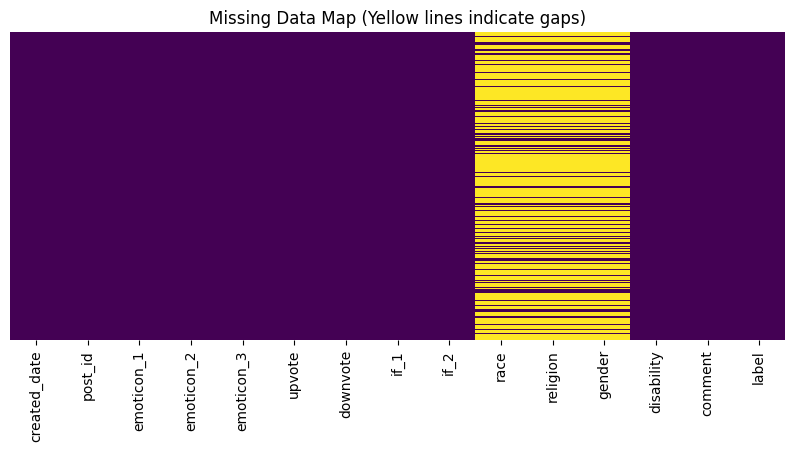

In [43]:
# Visualizing missing data in train dataset
plt.figure(figsize=(10, 4))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Map (Yellow lines indicate gaps)")
plt.show()

In [44]:
print("missing values in train dataset")
print(data.isna().sum())
print("*-"*50)

missing values in train dataset
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-


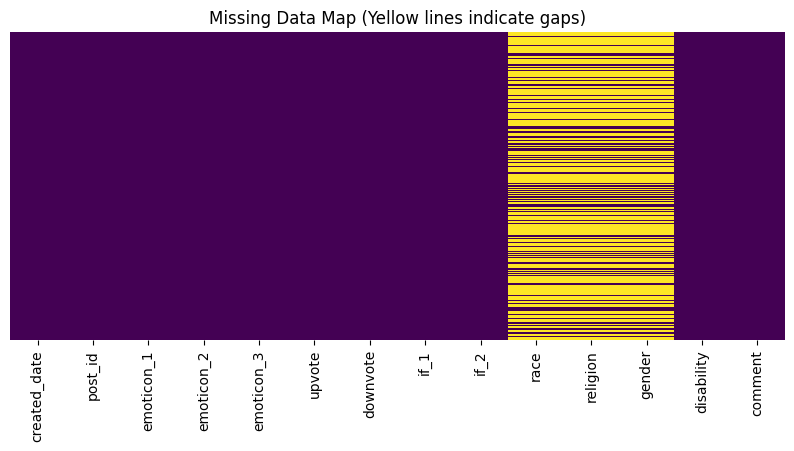

In [45]:
# Visualizing missing data in test datset
plt.figure(figsize=(10, 4))
sns.heatmap(test.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Map (Yellow lines indicate gaps)")
plt.show()

In [46]:
#percantage of nan values present in train data
print("total missing values preset in train datset in all column 'race', religion and gender is :",145423)
print("total percentage : ",(145423/198000)*100, "%")
print("-"*100)
#percantage of nan values present in test data
print("Total missing values are present in the test datset in all column 'race', 'religion' and 'gender' is :", 75269)
print("total percentage : ",(75269/102000)*100, "%")

total missing values preset in train datset in all column 'race', religion and gender is : 145423
total percentage :  73.4459595959596 %
----------------------------------------------------------------------------------------------------
Total missing values are present in the test datset in all column 'race', 'religion' and 'gender' is : 75269
total percentage :  73.79313725490196 %


*As a general rule of thumb, a column with over 50-70% missing data is a strong candidate for removal because there is not enough information to make reliable imputations, and keeping it may introduce bias or reduce model performance*

In [47]:
#dropping the columns contain the more than 70% nan values 
threshold = 0.7 * len(data)
new_data=data.dropna(axis=1, thresh=threshold).copy()
print("doppped successfully")
print("="*100)
print()
threshold = 0.5 * len(test)
new_test=test.dropna(axis=1, thresh=threshold).copy()
print("dropped successfully")
new_data.head()

doppped successfully

dropped successfully


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,False,"Today, the confederate flag...tomorrow, the na...",2


In [48]:
new_data["comment"].fillna("", inplace=True)

/tmp/ipykernel_17/1856230495.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_data["comment"].fillna("", inplace=True)


In [49]:
new_test["comment"].fillna("", inplace=True)

/tmp/ipykernel_17/3060491808.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_test["comment"].fillna("", inplace=True)


*checking for the duplicate values present in the dataset*

In [50]:
print(new_data.duplicated().sum())
print(new_test.duplicated().sum())

0
0


In [51]:
new_data["label"].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [52]:
def add_features_df(df):
    dt = pd.to_datetime(df['created_date'], errors='coerce', utc=True)
    df['hour'] = dt.dt.hour.fillna(-1).astype(int)
    df['dayofweek'] = dt.dt.dayofweek.fillna(-1).astype(int)

    # votes
    df['vote_total'] = df['upvote'] + df['downvote']
    df['vote_ratio'] = df['upvote'] / (df['vote_total'] + 1.0)
    df['controversy'] = df['downvote'] / (df['upvote'] + 1.0)
    df['upvote_log1p'] = np.log1p(df['upvote'])
    df['downvote_log1p'] = np.log1p(df['downvote'])

    # emoticons
    df['emoticon_sum'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']

    # disability to int
    df['disability'] = df['disability'].astype(int)
    df['text_length'] = df['comment'].astype(str).apply(len)
    df = df.drop(columns=['created_date'])
    return df


**Identifying the outleires in datset**

In [53]:
new_data = add_features_df(new_data)
new_test= add_features_df(new_test)

In [54]:
new_data["disability"] = new_data["disability"].astype(int)
new_test["disability"] = new_test["disability"].astype(int)


In [55]:
new_data.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label,hour,dayofweek,vote_total,vote_ratio,controversy,upvote_log1p,downvote_log1p,emoticon_sum,text_length
0,73,0,0,0,0,1,0,10,0,She might be a bright spot for a party keou on...,2,8,3,1,0.000000,1.0,0.000000,0.693147,0,118
1,39,0,0,0,6,0,0,4,0,"Under Alaska law, a non-tribal member is not b...",0,21,6,6,0.857143,0.0,1.945910,0.000000,0,644
2,31,0,1,1,0,0,0,10,0,in the future please spare me your strawman dr...,2,20,2,0,0.000000,0.0,0.000000,0.000000,2,751
3,39,0,0,0,5,0,0,10,0,"PS: That should have been ""rot"" instead of ""co...",2,22,6,5,0.833333,0.0,1.791759,0.000000,0,91
4,39,0,0,0,0,0,0,10,0,"Today, the confederate flag...tomorrow, the na...",2,23,5,0,0.000000,0.0,0.000000,0.000000,0,254


In [56]:
new_test.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,hour,dayofweek,vote_total,vote_ratio,controversy,upvote_log1p,downvote_log1p,emoticon_sum,text_length
0,72,2,0,0,4,1,0,10,0,Canada is being run by someone with the mental...,13,3,5,0.666667,0.2,1.609438,0.693147,2,72
1,123,0,0,0,0,0,0,10,0,And your comment is left-wing drivel,23,4,0,0.000000,0.0,0.000000,0.000000,0,36
2,120,0,0,0,3,0,0,4,0,http://talkingpointsmemo..com/dc/special-couns...,21,4,3,0.750000,0.0,1.386294,0.000000,0,69
3,123,0,0,0,0,0,0,4,0,"Trump jl Blames: The Secret Service, James Com...",3,5,0,0.000000,0.0,0.000000,0.000000,0,155
4,123,0,0,0,0,0,0,11,0,It was hard enough to get the stench out of th...,2,2,0,0.000000,0.0,0.000000,0.000000,0,77


In [57]:
num_cols = new_data.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)
print("="*100)
for col in num_cols:
    if col in new_data.columns:
        Q1 = new_data[col].quantile(0.25)
        Q3 = new_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = new_data[(new_data[col] < lower_bound) | (new_data[col] > upper_bound)]
        print(f"column '{col}': {len(outliers)} outliers detected.")
    else:
        print(f"column '{col}' not found in training data.")

# identifying the outlier in the train dataset
print("="*100)
print("for the test datset")
for col in num_cols:
    if col in new_test.columns:
        Q1 = new_test[col].quantile(0.25)
        Q3 = new_test[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = new_test[(new_test[col] < lower_bound) | (new_test[col] > upper_bound)]
        print(f"column '{col}': {len(outliers)} outliers detected.")
    else:
        print(f"column '{col}' not found in test data.")

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
       'downvote', 'if_1', 'if_2', 'disability', 'label', 'hour', 'dayofweek',
       'vote_total', 'vote_ratio', 'controversy', 'upvote_log1p',
       'downvote_log1p', 'emoticon_sum', 'text_length'],
      dtype='object')
column 'post_id': 4823 outliers detected.
column 'emoticon_1': 28922 outliers detected.
column 'emoticon_2': 8109 outliers detected.
column 'emoticon_3': 17165 outliers detected.
column 'upvote': 17304 outliers detected.
column 'downvote': 15173 outliers detected.
column 'if_1': 85 outliers detected.
column 'if_2': 3930 outliers detected.
column 'disability': 2743 outliers detected.
column 'label': 0 outliers detected.
column 'hour': 0 outliers detected.
column 'dayofweek': 0 outliers detected.
column 'vote_total': 14056 outliers detected.
column 'vote_ratio': 0 outliers detected.
column 'controversy': 42875 outliers detected.
column 'upvote_log1p': 915 outliers detected.
column 'downvote_log1p': 

In [58]:
import numpy as np

print("Handling Outliers for Training Data")

bounds_dict = {}  # store train bounds

for col in num_cols:
    if col in new_data.columns:
        
        lower_bound = new_data[col].quantile(0.05)
        upper_bound = new_data[col].quantile(0.95)

        bounds_dict[col] = (lower_bound, upper_bound)  # save bounds
        
        capped_count = ((new_data[col] < lower_bound) | 
                        (new_data[col] > upper_bound)).sum()

        new_data[col] = np.clip(new_data[col], lower_bound, upper_bound)

        print(f"Column '{col}': {capped_count} values capped in train.")
    else:
        print(f"Column '{col}' not found in training data.")

print("="*100)
print("Handling Outliers for Test Data")

for col in num_cols:
    if col in new_test.columns and col in bounds_dict:

        lower_bound, upper_bound = bounds_dict[col]  # use train bounds

        capped_count = ((new_test[col] < lower_bound) | 
                        (new_test[col] > upper_bound)).sum()

        new_test[col] = np.clip(new_test[col], lower_bound, upper_bound)

        print(f"Column '{col}': {capped_count} values capped in test.")
    else:
        print(f"Column '{col}' not found in test data.")

Handling Outliers for Training Data
Column 'post_id': 5904 values capped in train.
Column 'emoticon_1': 5440 values capped in train.
Column 'emoticon_2': 8109 values capped in train.
Column 'emoticon_3': 4148 values capped in train.
Column 'upvote': 9874 values capped in train.
Column 'downvote': 9743 values capped in train.
Column 'if_1': 85 values capped in train.
Column 'if_2': 4268 values capped in train.
Column 'disability': 2743 values capped in train.
Column 'label': 5469 values capped in train.
Column 'hour': 0 values capped in train.
Column 'dayofweek': 0 values capped in train.
Column 'vote_total': 8864 values capped in train.
Column 'vote_ratio': 9631 values capped in train.
Column 'controversy': 8425 values capped in train.
Column 'upvote_log1p': 9874 values capped in train.
Column 'downvote_log1p': 9743 values capped in train.
Column 'emoticon_sum': 9385 values capped in train.
Column 'text_length': 19376 values capped in train.
Handling Outliers for Test Data
Column 'post

## Data visualization on the train and test dataset

In [59]:
new_test.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,hour,dayofweek,vote_total,vote_ratio,controversy,upvote_log1p,downvote_log1p,emoticon_sum,text_length
0,72,2,0,0,4,1,0,10,0,Canada is being run by someone with the mental...,13,3,5,0.666667,0.2,1.609438,0.693147,2,72
1,120,0,0,0,0,0,0,10,0,And your comment is left-wing drivel,23,4,0,0.000000,0.0,0.000000,0.000000,0,36
2,120,0,0,0,3,0,0,4,0,http://talkingpointsmemo..com/dc/special-couns...,21,4,3,0.750000,0.0,1.386294,0.000000,0,69
3,120,0,0,0,0,0,0,4,0,"Trump jl Blames: The Secret Service, James Com...",3,5,0,0.000000,0.0,0.000000,0.000000,0,155
4,120,0,0,0,0,0,0,10,0,It was hard enough to get the stench out of th...,2,2,0,0.000000,0.0,0.000000,0.000000,0,77


In [60]:
new_data.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label,hour,dayofweek,vote_total,vote_ratio,controversy,upvote_log1p,downvote_log1p,emoticon_sum,text_length
0,73,0,0,0,0,1,0,10,0,She might be a bright spot for a party keou on...,2,8,3,1,0.000000,1.0,0.000000,0.693147,0,118
1,39,0,0,0,6,0,0,4,0,"Under Alaska law, a non-tribal member is not b...",0,21,6,6,0.857143,0.0,1.945910,0.000000,0,644
2,31,0,0,1,0,0,0,10,0,in the future please spare me your strawman dr...,2,20,2,0,0.000000,0.0,0.000000,0.000000,2,751
3,39,0,0,0,5,0,0,10,0,"PS: That should have been ""rot"" instead of ""co...",2,22,6,5,0.833333,0.0,1.791759,0.000000,0,91
4,39,0,0,0,0,0,0,10,0,"Today, the confederate flag...tomorrow, the na...",2,23,5,0,0.000000,0.0,0.000000,0.000000,0,254


**visualising the classes of the Target columns to check class imbance**

Index([0, 2, 1], dtype='int64', name='label')


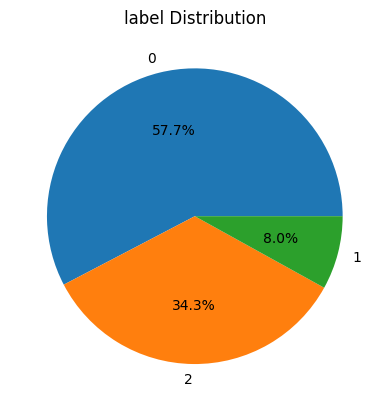

In [61]:
#check for class imbalance.
from matplotlib import pyplot as plt

counts = new_data["label"].value_counts()
print(counts.index)
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("label Distribution")
plt.show()

checking the correlation between the all the columns with the target  columns

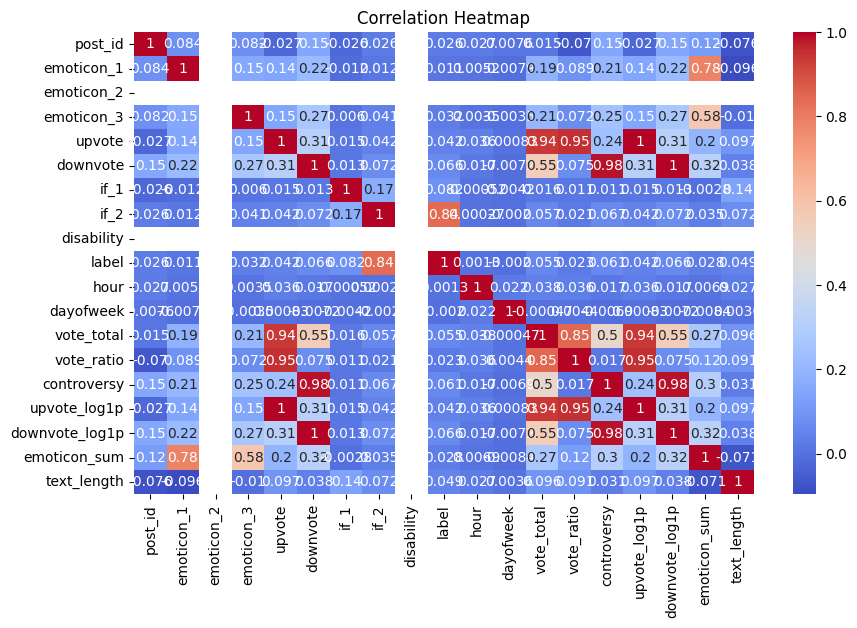

In [62]:
plt.figure(figsize=(10, 6))
sns.heatmap(new_data[num_cols].corr(method='spearman'), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

***wordcloud to understand the most common words in  all the classes inn label***

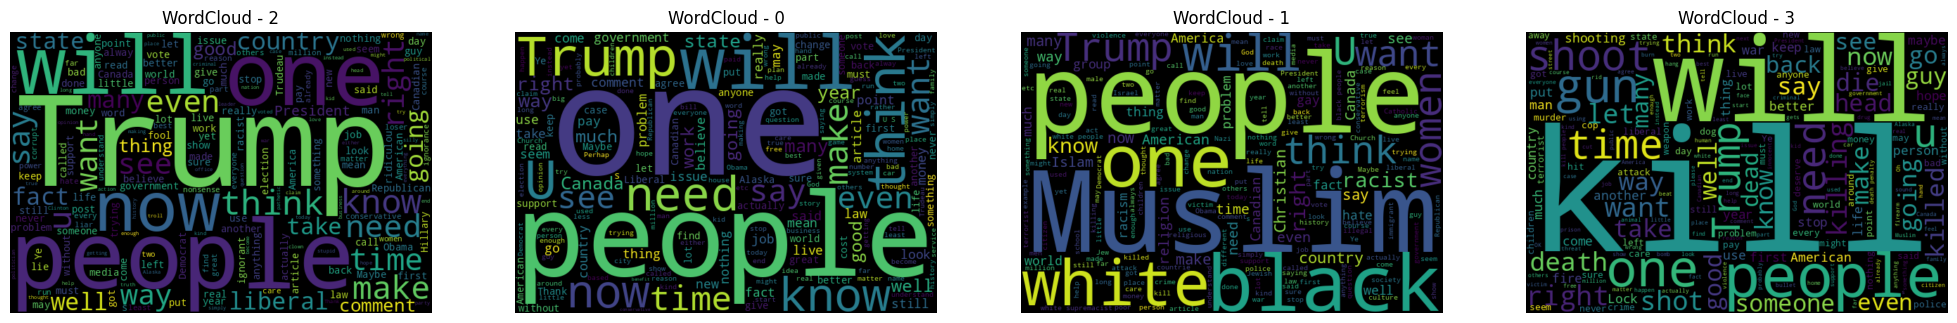

In [63]:
label = data["label"].unique()

plt.figure(figsize=(25,15))
for i, s in enumerate(label):
    text = " ".join(data[data.label == s]["comment"].astype(str))

    wc = WordCloud(width=600, height=400, background_color='black',
                   stopwords=STOPWORDS).generate(text)
    
    plt.subplot(1, len(label), i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud - {s}")


plt.show()

## preprocessing train and test data

In [64]:
labels=new_data["label"]
features=new_data.drop(["label"], axis=1)

In [65]:
labels.head()

0    2
1    0
2    2
3    2
4    2
Name: label, dtype: int64

In [66]:
features["comment"] = features["comment"].astype(str)
new_test["comment"] = new_test["comment"].astype(str)

In [67]:
new_test.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,hour,dayofweek,vote_total,vote_ratio,controversy,upvote_log1p,downvote_log1p,emoticon_sum,text_length
0,72,2,0,0,4,1,0,10,0,Canada is being run by someone with the mental...,13,3,5,0.666667,0.2,1.609438,0.693147,2,72
1,120,0,0,0,0,0,0,10,0,And your comment is left-wing drivel,23,4,0,0.000000,0.0,0.000000,0.000000,0,36
2,120,0,0,0,3,0,0,4,0,http://talkingpointsmemo..com/dc/special-couns...,21,4,3,0.750000,0.0,1.386294,0.000000,0,69
3,120,0,0,0,0,0,0,4,0,"Trump jl Blames: The Secret Service, James Com...",3,5,0,0.000000,0.0,0.000000,0.000000,0,155
4,120,0,0,0,0,0,0,10,0,It was hard enough to get the stench out of th...,2,2,0,0.000000,0.0,0.000000,0.000000,0,77


In [68]:
features.isna().sum()

post_id           0
emoticon_1        0
emoticon_2        0
emoticon_3        0
upvote            0
downvote          0
if_1              0
if_2              0
disability        0
comment           0
hour              0
dayofweek         0
vote_total        0
vote_ratio        0
controversy       0
upvote_log1p      0
downvote_log1p    0
emoticon_sum      0
text_length       0
dtype: int64

In [69]:
features.shape

(198000, 19)

In [70]:
new_test.isna().sum()

post_id           0
emoticon_1        0
emoticon_2        0
emoticon_3        0
upvote            0
downvote          0
if_1              0
if_2              0
disability        0
comment           0
hour              0
dayofweek         0
vote_total        0
vote_ratio        0
controversy       0
upvote_log1p      0
downvote_log1p    0
emoticon_sum      0
text_length       0
dtype: int64

In [71]:
import re
def clean_text(t):
    t = t.lower()
    t = re.sub(r"http\S+|www\S+", "", t)
    t = re.sub(r"[^a-z\s]", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

In [72]:
features["comment"] = features["comment"].apply(clean_text)
new_test["comment"] = new_test["comment"].apply(clean_text)


In [73]:
features["comment"]

0         she might be a bright spot for a party keou on...
1         under alaska law a nontribal member is not bou...
2         in the future please spare me your strawman dr...
3         ps that should have been rot instead of corrup...
4         today the confederate flagtomorrow the nazi fl...
                                ...                        
197995    why save people who are bent on selfdestructio...
197996    trudeau is not only undemocratic but also innu...
197997    block all exports no humanitarian relief and a...
197998    really black kids seeing that is better than g...
197999    sounds likely since but now scientists have fo...
Name: comment, Length: 198000, dtype: object

In [74]:
features.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,hour,dayofweek,vote_total,vote_ratio,controversy,upvote_log1p,downvote_log1p,emoticon_sum,text_length
0,73,0,0,0,0,1,0,10,0,she might be a bright spot for a party keou on...,8,3,1,0.000000,1.0,0.000000,0.693147,0,118
1,39,0,0,0,6,0,0,4,0,under alaska law a nontribal member is not bou...,21,6,6,0.857143,0.0,1.945910,0.000000,0,644
2,31,0,0,1,0,0,0,10,0,in the future please spare me your strawman dr...,20,2,0,0.000000,0.0,0.000000,0.000000,2,751
3,39,0,0,0,5,0,0,10,0,ps that should have been rot instead of corrup...,22,6,5,0.833333,0.0,1.791759,0.000000,0,91
4,39,0,0,0,0,0,0,10,0,today the confederate flagtomorrow the nazi fl...,23,5,0,0.000000,0.0,0.000000,0.000000,0,254


In [75]:
x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42, stratify=labels)

In [76]:
x_train.isnull().sum()

post_id           0
emoticon_1        0
emoticon_2        0
emoticon_3        0
upvote            0
downvote          0
if_1              0
if_2              0
disability        0
comment           0
hour              0
dayofweek         0
vote_total        0
vote_ratio        0
controversy       0
upvote_log1p      0
downvote_log1p    0
emoticon_sum      0
text_length       0
dtype: int64

In [77]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158400 entries, 180416 to 80147
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   post_id         158400 non-null  int64  
 1   emoticon_1      158400 non-null  int64  
 2   emoticon_2      158400 non-null  int64  
 3   emoticon_3      158400 non-null  int64  
 4   upvote          158400 non-null  int64  
 5   downvote        158400 non-null  int64  
 6   if_1            158400 non-null  int64  
 7   if_2            158400 non-null  int64  
 8   disability      158400 non-null  int64  
 9   comment         158400 non-null  object 
 10  hour            158400 non-null  int64  
 11  dayofweek       158400 non-null  int64  
 12  vote_total      158400 non-null  int64  
 13  vote_ratio      158400 non-null  float64
 14  controversy     158400 non-null  float64
 15  upvote_log1p    158400 non-null  float64
 16  downvote_log1p  158400 non-null  float64
 17  emoticon_su

In [78]:
num_cols = x_train.select_dtypes(include=["int64", "float64"]).columns

In [79]:
text_preprocessor = Pipeline([
    ("selector", FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ("tfidf", TfidfVectorizer(lowercase=True, max_features=8000, stop_words="english", sublinear_tf=True))
])

# ColumnTransformer
ct = ColumnTransformer([
    ('term_freq', text_preprocessor, 'comment'),
    ('scale', MinMaxScaler(),num_cols)
], remainder='passthrough', verbose_feature_names_out=False)

In [80]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC 
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix,classification_report


models = {
    "LogisticRegression": LogisticRegression(max_iter=5000,class_weight="balanced", solver="saga"),
    "SGDclassfier": SGDClassifier(loss="log_loss", max_iter=5000),
    "SVM": LinearSVC(class_weight="balanced"),
    "NaiveBayes": ComplementNB(),
    "multnb" : MultinomialNB(),
    "lgbm" :LGBMClassifier(
    objective='multiclass',
    num_class=4,
    class_weight='balanced',
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
}

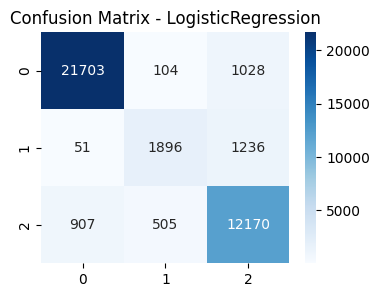

LogisticRegression Accuracy: 0.9033
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.76      0.60      0.67      3183
           2       0.84      0.90      0.87     13582

    accuracy                           0.90     39600
   macro avg       0.85      0.81      0.83     39600
weighted avg       0.90      0.90      0.90     39600

----------------------------------------------------------------------------------------------------


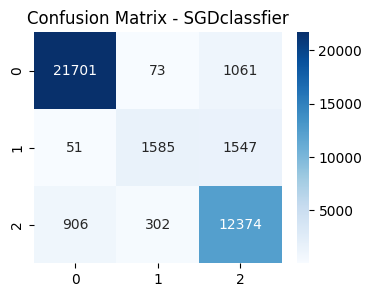

SGDclassfier Accuracy: 0.9005
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.81      0.50      0.62      3183
           2       0.83      0.91      0.87     13582

    accuracy                           0.90     39600
   macro avg       0.86      0.79      0.81     39600
weighted avg       0.90      0.90      0.90     39600

----------------------------------------------------------------------------------------------------


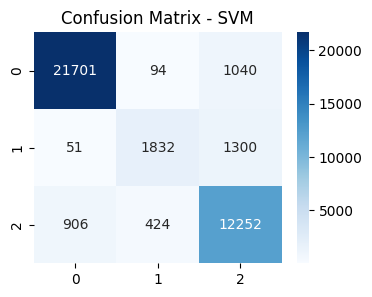

SVM Accuracy: 0.9037
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.78      0.58      0.66      3183
           2       0.84      0.90      0.87     13582

    accuracy                           0.90     39600
   macro avg       0.86      0.81      0.83     39600
weighted avg       0.90      0.90      0.90     39600

----------------------------------------------------------------------------------------------------


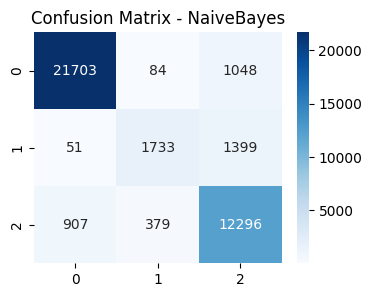

NaiveBayes Accuracy: 0.9023
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.79      0.54      0.64      3183
           2       0.83      0.91      0.87     13582

    accuracy                           0.90     39600
   macro avg       0.86      0.80      0.82     39600
weighted avg       0.90      0.90      0.90     39600

----------------------------------------------------------------------------------------------------


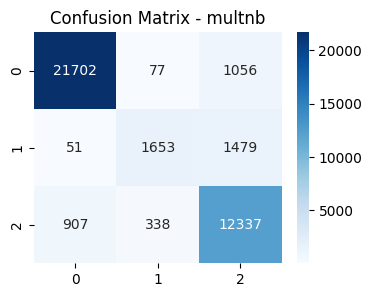

multnb Accuracy: 0.9013
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.80      0.52      0.63      3183
           2       0.83      0.91      0.87     13582

    accuracy                           0.90     39600
   macro avg       0.86      0.79      0.82     39600
weighted avg       0.90      0.90      0.90     39600

----------------------------------------------------------------------------------------------------


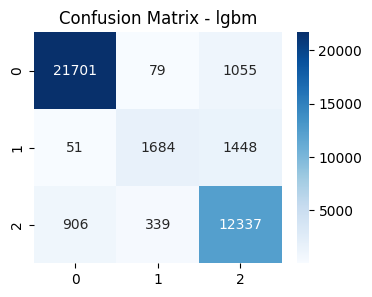

lgbm Accuracy: 0.9021
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.80      0.53      0.64      3183
           2       0.83      0.91      0.87     13582

    accuracy                           0.90     39600
   macro avg       0.86      0.80      0.82     39600
weighted avg       0.90      0.90      0.90     39600

----------------------------------------------------------------------------------------------------


In [81]:
results = {}
for name, model in models.items():
    pipe=Pipeline([
    ("preprocess", ct),
    ("model", SGDClassifier(loss="log_loss", max_iter=500))])
    pipe.fit(x_train, y_train)
    preds = pipe.predict(x_val)
    cm = confusion_matrix(y_val, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    acc=accuracy_score(y_val, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_val, preds))
    print("-" * 100)

In [82]:
results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
2,SVM,0.903662
0,LogisticRegression,0.903258
3,NaiveBayes,0.902323
5,lgbm,0.902071
4,multnb,0.901313
1,SGDclassfier,0.900505


## Hyperparameter tuning for the all  best models

In [83]:
# # hyperparamater tuning for the Sgd classifier
# from sklearn.model_selection import RandomizedSearchCV

# param_sgd1 = {
#     "preprocessor__term_freq__tfidf__max_df": (0.5, 0.75, 1.0),
#     "preprocessor__term_freq__tfidf__max_features": (None, 5000,7000, 8000, 10000),
#     "preprocessor__term_freq__tfidf__ngram_range": ((1, 1), (1, 2)),

#     'clf__alpha': [1e-5, 1e-4, 1e-3, 0.01, 0.1],
#     'clf__penalty': ['l2', 'l1', 'elasticnet'],
#     'clf__max_iter': (10, 50, 80),
#     'clf__learning_rate': ['optimal', 'adaptive', 'invscaling'],
#     'clf__eta0': [0.01, 0.1, 1.0],
#     'clf__class_weight': ['balanced', None] 
# }


# sgd_pipeline = Pipeline([
#     ('preprocessor', ct),
#     ('clf', SGDClassifier(
#         max_iter=2000, 
#         tol=1e-4, 
#         early_stopping=True, # Important for speed
#         n_jobs=-1,
#         random_state=42
#     ))
# ])

# print(sgd_pipeline.get_params().keys())

# random_search = RandomizedSearchCV(
#     sgd_pipeline,
#     param_distributions=param_sgd1,
#     n_iter=20,           # 20 random models
#     cv=3,                # 3-Fold Cross Validation
#     scoring='f1_weighted', # Optimize for F1 due to imbalance
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# import warnings
# warnings.filterwarnings('ignore')
# random_search.fit(features, labels)

# print(f"Best Score (F1): {random_search.best_score_:.4f}")
# print(f"Best Params: {random_search.best_params_}")

In [84]:
# best_pipe = random_search.best_estimator_

# pred = best_pipe.predict(x_val)
# print("Tuned holdout F1 macro:", f1_score(y_val, pred, average='macro'))
# print(classification_report(y_val, pred, digits=3))


In [85]:
# from xgboost import XGBClassifier
# from sklearn.model_selection import RandomizedSearchCV

# # 1. Initialize the XGBoost Classifier
# # 'tree_method="hist"' is essential for speed at 200k rows
# xgb_clf = XGBClassifier(
#     tree_method='hist', 
#     device="cpu",   
#     eval_metric='logloss',
#     random_state=42
# )

# # 2. Define the Search Space
# param_grid = {
#     'clf__n_estimators': [100, 300, 500],
#     'clf__learning_rate': [0.01, 0.05, 0.1],
#     'clf__max_depth': [3, 6, 9],
#     'clf__subsample': [0.8, 1.0],
#     'clf__colsample_bytree': [0.3, 0.5, 0.7],
#     'clf__gamma': [0, 0.1, 0.5],
    
#     # this one is fine IF your ColumnTransformer step is named 'text'
#     'preprocessor__term_freq__tfidf__max_features': [5000, 10000]
# }

# pipeline = Pipeline([
#     ('preprocessor', ct),
#     ('clf', xgb_clf)])

# # 3. Randomized Search
# xgb_search = RandomizedSearchCV(
#     pipeline, # The pipeline containing your preprocessor
#     param_distributions=param_grid,
#     n_iter=20, 
#     cv=3, 
#     scoring='f1_weighted',
#     n_jobs=-1, 
#     verbose=1
# )

# xgb_search.fit(features, labels)

In [86]:
# best_pipe = xgb_search.best_estimator_

# pred = best_pipe.predict(x_val)
# print("Tuned holdout F1 macro:", f1_score(y_val, pred, average='macro'))
# print(classification_report(y_val, pred, digits=3))


## Fine tuning Loght gbm 

In [87]:
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# param_dist = {
#     # TF-IDF (keep small search)
#     'pre__txt__tfidf__max_features': [15000, 20000, 30000],
#     'pre__txt__tfidf__ngram_range': [(1,1), (1,2)],
#     'pre__txt__tfidf__min_df': [3, 5, 10],
#     'pre__txt__tfidf__max_df': [0.90, 0.95, 0.98],

#     # LightGBM
#     'clf__n_estimators': [800, 1200, 1600],
#     'clf__learning_rate': [0.03, 0.05, 0.07],
#     'clf__num_leaves': [63, 127, 255],
#     'clf__min_child_samples': [10, 20, 40, 80],
#     'clf__subsample': [0.7, 0.85, 1.0],
#     'clf__colsample_bytree': [0.7, 0.85, 1.0],
#     'clf__reg_alpha': [0.0, 0.1, 0.5],
#     'clf__reg_lambda': [0.0, 0.1, 0.5],
# }


# lgbm = LGBMClassifier(
#     objective='multiclass',
#     num_class=4,
#     class_weight='balanced',
#     n_estimators=1200,
#     learning_rate=0.05,
#     num_leaves=127,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

# pipeline = Pipeline([
#     ('preprocessor', ct),
#     ('clf', lgbm)])

# rs = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=param_dist,
#     n_iter=12,
#     scoring='f1_macro',
#     cv=cv,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# rs.fit(features, labels)

# print("Best CV F1 macro:", rs.best_score_)
# print("Best params:", rs.best_params_)


In [88]:
# best_pipe = rs.best_estimator_

# pred = best_pipe.predict(x_val)
# print("Tuned holdout F1 macro:", f1_score(y_val, pred, average='macro'))
# print(classification_report(y_val, pred, digits=3))


### Final model

In [89]:
# best_pipe.fit(features, labels)


In [90]:
# y_preds = best_pipe.predict(new_test)

In [91]:
final_pipe = Pipeline([
    ("preprocess", ct),
    ("model", SGDClassifier(loss="log_loss", max_iter=2000))
])

final_pipe.fit(features,labels)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('term_freq',
                                                  Pipeline(steps=[('selector',
                                                                   FunctionTransformer(func=<function <lambda> at 0x795809aa7d80>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=8000,
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'comment'),
                                                 ('scale', MinMaxScaler(),
                                                  Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
       'downvote', 'if_1', 'if_2', 'disability', 'hour', 'dayofweek',
       'vote_total', 'vote_ratio', 'controversy', 'upvote_log1p',
       'downvote_log1p', 'emoticon_sum', 'text_length'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('model', SGDClassifier(loss='log_loss', max_iter=2000))])

In [92]:
y_preds = final_pipe.predict(new_test)

In [93]:
submission = pd.DataFrame({"ID": range(1,new_test.shape[0]+1), "label": y_preds}) 
submission.head()

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


In [94]:
submission["label"].value_counts()

label
0    58107
2    38312
1     5581
Name: count, dtype: int64

In [95]:
submission.shape

(102000, 2)

In [96]:

submission.to_csv('submission.csv', index=False)